Đã đọc 30,336 hàng từ MySQL
 Sau khi tạo lag features: 30,168 hàng

Train: 25,824
Test : 4,344

⏳ Training Linear Regression...
✅ Done
⏳ Training Random Forest...
✅ Done
⏳ Training XGBoost...
✅ Done

BẢNG SO SÁNH 3 MODEL (TRAIN vs TEST)
            Model  Train_R2  Test_R2    Gap  Test_RMSE  Test_MAE
Linear Regression    0.8228   0.7769 0.0459      25.12     17.17
    Random Forest    0.9120   0.7816 0.1304      24.85     16.60
          XGBoost    0.8682   0.7850 0.0832      24.66     16.43

📌 MODEL SELECTION
               Model  Test_R2  Test_RMSE     Gap     score
0  Linear Regression   0.7769      25.12  0.0459  0.376900
1      Random Forest   0.7816      24.85  0.1304  0.016383
2            XGBoost   0.7850      24.66  0.0832  0.520148

→ Best model: XGBoost


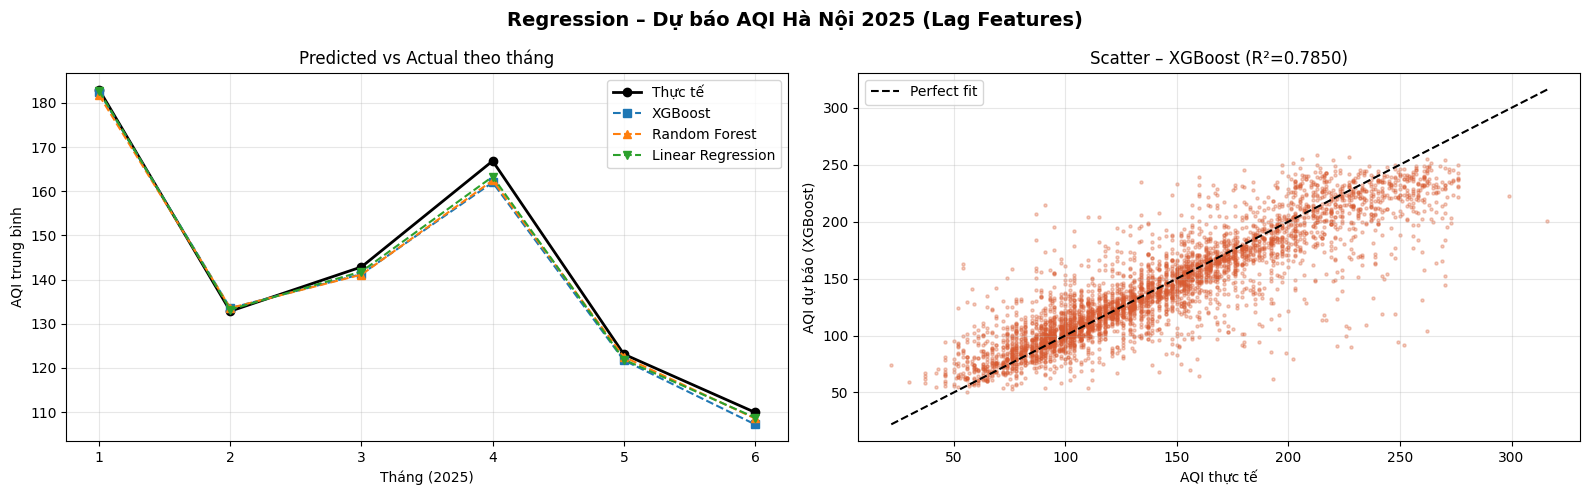


✅ Saved: best_model_regression.pkl (XGBoost)


In [2]:
"""
Regression – Dự báo AQI Hà Nội (Realistic Forecasting)
=========================================================
Features: thời tiết + thời gian + AQI quá khứ (lag)
Train: 2022–2024 | Test: 2025
"""
# =====================================================
# THỬ NGHIỆM KỊCH BẢN: KHÔNG CÓ DỮ LIỆU REAL-TIME (ONLY LAG FEATURES)
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import os
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
df = pd.read_sql('SELECT * FROM aqi_data', con=engine)
print(f"Đã đọc {len(df):,} hàng từ MySQL")

df.columns = df.columns.str.strip().str.lower()
df['local_time'] = pd.to_datetime(df['local_time'])

df = df.sort_values('local_time').reset_index(drop=True)

# ---------- LAGS ----------
df['aqi_lag_1']   = df['aqi'].shift(1)
df['aqi_lag_2']   = df['aqi'].shift(2)
df['aqi_lag_3']   = df['aqi'].shift(3)


df['aqi_lag_6']   = df['aqi'].shift(6)
df['aqi_lag_12']  = df['aqi'].shift(12)


df['aqi_lag_24']  = df['aqi'].shift(24)
df['aqi_lag_48']  = df['aqi'].shift(48)


df['aqi_lag_168'] = df['aqi'].shift(168)


# ---------- ROLLING ----------
df['aqi_roll_6'] = (
    df['aqi']
    .shift(1)
    .rolling(6)
    .mean()
)


df['aqi_roll_12'] = (
    df['aqi']
    .shift(1)
    .rolling(12)
    .mean()
)


df['aqi_roll_24'] = (
    df['aqi']
    .shift(1)
    .rolling(24)
    .mean()
)


df['aqi_roll_48'] = (
    df['aqi']
    .shift(1)
    .rolling(48)
    .mean()
)


# ---------- EMA ----------
df['aqi_ema_12'] = (
    df['aqi']
    .shift(1)
    .ewm(span=12)
    .mean()
)


df['aqi_ema_24'] = (
    df['aqi']
    .shift(1)
    .ewm(span=24)
    .mean()
)


# ---------- TREND ----------
df['aqi_trend_1'] = (
    df['aqi_lag_1'] - df['aqi_lag_2']
)


df['aqi_trend_6'] = (
    df['aqi_lag_1'] - df['aqi_lag_6']
)


df['aqi_trend_24'] = (
    df['aqi_lag_1'] - df['aqi_lag_24']
)


# =====================================================
#  PM2.5 FEATURES 
# =====================================================

df['pm25_lag_1'] = df['pm25'].shift(1)
df['pm25_lag_6'] = df['pm25'].shift(6)
df['pm25_lag_24'] = df['pm25'].shift(24)


df['pm25_roll_24'] = (
    df['pm25']
    .shift(1)
    .rolling(24)
    .mean()
)


df['pm25_ema_24'] = (
    df['pm25']
    .shift(1)
    .ewm(span=24)
    .mean()
)

df = df.dropna().copy()

print(f" Sau khi tạo lag features: {len(df):,} hàng")

# =====================================================
# FEATURES & TARGET
# =====================================================

FEATURES = [

    # WEATHER
    'clouds',
    'precipitation',
    'pressure',
    'relative_humidity',
    'temperature',
    'uv_index',
    'wind_speed',

    # TIME
    'month',
    'hour',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'season',

    # AQI LAG
    'aqi_lag_1',
    'aqi_lag_2',
    'aqi_lag_3',

    'aqi_lag_6',
    'aqi_lag_12',

    'aqi_lag_24',
    'aqi_lag_48',

    'aqi_lag_168',

    # AQI ROLLING
    'aqi_roll_6',
    'aqi_roll_12',
    'aqi_roll_24',
    'aqi_roll_48',

    # AQI EMA
    'aqi_ema_12',
    'aqi_ema_24',

    # AQI TREND
    'aqi_trend_1',
    'aqi_trend_6',
    'aqi_trend_24',

    # PM2.5
    'pm25_lag_1',
    'pm25_lag_6',
    'pm25_lag_24',

    'pm25_roll_24',
    'pm25_ema_24'
]

TARGET = 'aqi'

# =====================================================
# TRAIN / TEST SPLIT
# =====================================================

train = df[df['year'] < 2025].copy()
test  = df[df['year'] == 2025].copy()

X_train = train[FEATURES]
y_train = train[TARGET]

X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"\nTrain: {len(train):,}")
print(f"Test : {len(test):,}")

# =====================================================
# FUNCTION METRICS
# =====================================================

def get_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

models = {}

# =====================================================
# LINEAR REGRESSION
# =====================================================

print("\n⏳ Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train_pred = lr.predict(X_train)
lr_test_pred  = lr.predict(X_test)

models['Linear Regression'] = {
    'model': lr,
    'train_pred': lr_train_pred,
    'test_pred': lr_test_pred
}
print("✅ Done")

# =====================================================
# RANDOM FOREST
# =====================================================

print("⏳ Training Random Forest...")
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred  = rf.predict(X_test)

models['Random Forest'] = {
    'model': rf,
    'train_pred': rf_train_pred,
    'test_pred': rf_test_pred
}
print("✅ Done")

# =====================================================
# XGBOOST
# =====================================================

print("⏳ Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=1200,
    learning_rate=0.02,

    max_depth=4,
    min_child_weight=12,

    subsample=0.70,
    colsample_bytree=0.70,

    gamma=0.5,

    reg_alpha=0.5,
    reg_lambda=5.0,

    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred  = xgb_model.predict(X_test)

models['XGBoost'] = {
    'model': xgb_model,
    'train_pred': xgb_train_pred,
    'test_pred': xgb_test_pred
}
print("✅ Done")

# =====================================================
# RESULTS TABLE (TRAIN + TEST R²)
# =====================================================
results = []
for name, obj in models.items():

    train_m = get_metrics(y_train, obj['train_pred'])
    test_m  = get_metrics(y_test, obj['test_pred'])

    results.append({
        'Model': name,

        'Train_R2': round(train_m['R2'], 4),
        'Test_R2': round(test_m['R2'], 4),
        'Gap':      round(train_m['R2'] - test_m['R2'], 4),

        'Test_RMSE': round(test_m['RMSE'], 2),

        'Test_MAE': round(test_m['MAE'], 2),
    })

results = pd.DataFrame(results)

print("\n" + "="*70)
print("BẢNG SO SÁNH 3 MODEL (TRAIN vs TEST)")
print("="*70)
print(results.to_string(index=False))

# =====================================================
# BEST MODEL (IMPROVED SELECTION)
# =====================================================

# Normalize cả 2 cột về cùng scale
results['rmse_norm'] = (results['Test_RMSE'] - results['Test_RMSE'].min()) / \
                       (results['Test_RMSE'].max() - results['Test_RMSE'].min() + 1e-9)
results['gap_norm']  = (results['Gap'] - results['Gap'].min()) / \
                       (results['Gap'].max() - results['Gap'].min() + 1e-9)

results['score'] = results['Test_R2'] - 0.4 * results['rmse_norm'] - 0.6 * results['gap_norm']

best_model_name = results.loc[results['score'].idxmax(), 'Model']
best_preds = models[best_model_name]['test_pred']

print("\n📌 MODEL SELECTION")
print(results[['Model', 'Test_R2', 'Test_RMSE', 'Gap', 'score']])
print(f"\n→ Best model: {best_model_name}")

# =====================================================
# VISUALIZATION
# =====================================================
test_plot = test.copy()

test_plot['pred_lr']  = lr_test_pred
test_plot['pred_rf']  = rf_test_pred
test_plot['pred_xgb'] = xgb_test_pred

monthly = test_plot.groupby('month').agg(
    actual=('aqi', 'mean'),
    lr=('pred_lr', 'mean'),
    rf=('pred_rf', 'mean'),
    xgb=('pred_xgb', 'mean')
).reset_index()

# lấy R2 của best model
best_r2 = results.loc[results['Model'] == best_model_name, 'Test_R2'].values[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Regression – Dự báo AQI Hà Nội 2025 (Lag Features)',
             fontsize=14, fontweight='bold')

# =========================
# Subplot 1
# =========================
ax1 = axes[0]
months = monthly['month']

ax1.plot(months, monthly['actual'], 'ko-', lw=2, label='Thực tế')
ax1.plot(months, monthly['xgb'], 's--', label='XGBoost')
ax1.plot(months, monthly['rf'], '^--', label='Random Forest')
ax1.plot(months, monthly['lr'], 'v--', label='Linear Regression')

ax1.set_xlabel('Tháng (2025)')
ax1.set_ylabel('AQI trung bình')
ax1.set_title('Predicted vs Actual theo tháng')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xticks(months)

# =========================
# Subplot 2
# =========================
ax2 = axes[1]
ax2.scatter(y_test, best_preds, alpha=0.3, s=5, color='#D85A30')

lims = [min(y_test.min(), best_preds.min()),
        max(y_test.max(), best_preds.max())]

ax2.plot(lims, lims, 'k--', lw=1.5, label='Perfect fit')
ax2.set_xlabel('AQI thực tế')
ax2.set_ylabel(f'AQI dự báo ({best_model_name})')
ax2.set_title(f'Scatter – {best_model_name} (R²={best_r2:.4f})')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================
# SAVE MODEL
# =====================================================

joblib.dump(models[best_model_name]['model'], 'best_model_regression.pkl')

print(f"\n✅ Saved: best_model_regression.pkl ({best_model_name})")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
df = pd.read_sql('SELECT * FROM aqi_data', con=engine)
print(f"Đã đọc {len(df):,} hàng từ MySQL")

df.columns = df.columns.str.strip().str.lower()
df['local_time'] = pd.to_datetime(df['local_time'])

df = df.sort_values('local_time').reset_index(drop=True)
# =====================================================
# THỬ NGHIỆM KỊCH BẢN: CÓ DỮ LIỆU REAL-TIME (SENSOR DATA)
# =====================================================

# 1. Định nghĩa bộ Feature Real-time (Bao gồm các nồng độ chất đo được ngay lúc đó)
REALTIME_FEATURES = [
    'co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 
    'clouds', 'precipitation', 'pressure', 'relative_humidity', 
    'temperature', 'uv_index', 'wind_speed',
    'month', 'hour', 'day_of_week', 'is_weekend', 'season'
]

X_train_rt = train[REALTIME_FEATURES]
X_test_rt  = test[REALTIME_FEATURES]

print(f"\n--- Đang đánh giá kịch bản Real-time với {len(REALTIME_FEATURES)} features ---")

rt_results = []
rt_models = {
    'LinearRegression_Realtime': LinearRegression(),
    'RandomForest_Realtime': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost_Realtime': xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
}

for name, model in rt_models.items():
    model.fit(X_train_rt, y_train)
    preds = model.predict(X_test_rt)
    metrics = get_metrics(y_test, preds)
    
    rt_results.append({
        'Model': name,
        'R2_Test': round(metrics['R2'], 4),
        'RMSE': round(metrics['RMSE'], 2),
        'MAE': round(metrics['MAE'], 2)
    })

rt_df = pd.DataFrame(rt_results)
print("\n" + "="*50)
print("KẾT QUẢ DỰ ĐOÁN KHI CÓ DỮ LIỆU REAL-TIME")
print("="*50)
print(rt_df.sort_values('R2_Test', ascending=False).to_string(index=False))

best_rt_model = rt_df.loc[rt_df['R2_Test'].idxmax(), 'Model']
print(f"\n🏆 Model dự đoán AQI đúng nhất khi có Real-time: {best_rt_model}")

Đã đọc 30,336 hàng từ MySQL

--- Đang đánh giá kịch bản Real-time với 18 features ---

KẾT QUẢ DỰ ĐOÁN KHI CÓ DỮ LIỆU REAL-TIME
                    Model  R2_Test  RMSE   MAE
    RandomForest_Realtime   0.9879  5.84  0.56
         XGBoost_Realtime   0.9866  6.16  1.37
LinearRegression_Realtime   0.8537 20.34 14.76

🏆 Model dự đoán AQI đúng nhất khi có Real-time: RandomForest_Realtime
